In [1]:
from torch import optim
import networkx as nx
import matplotlib.pyplot as plt
from pykeen.triples import TriplesFactory
import pandas as pd
from pykeen.training.callbacks import TrainingCallback
import importlib
import machine_learning_2 as machine_learning
import torch
importlib.reload(machine_learning)

<module 'machine_learning_2' from '/Users/chrisdefra/Documents/oxford/KGS/c73f8a33-88eb-4884-842f-456da3be9123/assignment/machine_learning_2.py'>

In [2]:
triples_df = pd.read_csv('./data/csvs/training-triples.csv')

triples_df

,Hormone,_c1,Organ
0,Cyst and pseudocyst,isEtiologyOf,Other benign mass
1,Primary aldosteronism,isEtiologyOf,Adrenocortical adenoma or macronodular bilater...
2,Hemorrhage,isEtiologyOf,Other benign mass
3,Myelolipoma,isEtiologyOf,Other benign mass
4,Overt Cushing’s syndrome,isEtiologyOf,Adrenocortical adenoma or macronodular bilater...
...,...,...,...
361,Aldosterone,secretedBy,Zona glomerulosa
362,Androstenedione,secretedBy,Zona reticularis
363,Cortisone,secretedBy,Zona fasciculata
364,Dehydroepiandrosterone sulfate,secretedBy,Zona reticularis


In [3]:
triples_df['Hormone'].unique()

array(['Cyst and pseudocyst', 'Primary aldosteronism', 'Hemorrhage',
       'Myelolipoma', 'Overt Cushing’s syndrome', 'Ganglioneuroma',
       'Nonfunctioning', 'Mild autonomous cortisol  secretion',
       'Schwannoma', "Addison's disease", 'Progesterone',
       'norepinephrine', 'dopamine', 'Chromaffin cells', 'L cells',
       'Lactotrophs of anterior pituitary', 'Pancreatic β-cells',
       'Thyrotropes', 'Zona fasciculata',
       'Beta cells of Islets of Langerhans', 'Thyroid follicular cell',
       'Cardiac myocytes', 'PP cells', 'Parathyroid chief cell',
       'Parvocellular neurosecretory neurons',
       'Alpha cells of Islets of Langerhans', 'Zona glomerulosa',
       'Zona reticularis', 'Magnocellular neurosecretory cells',
       'Myocytes', 'Delta cells in islets', 'Adipocytes', 'Somatotropes',
       'Parafollicular cell', 'Corticotrope', 'Gonadotropes',
       'Neuroendocrince cells', 'Jejunum', 'Gastric Mucosa',
       'Substantia nigra', 'Islets of Langerhans', 'A

In [4]:
entity_counts = pd.concat([triples_df['Hormone'], triples_df['Organ']]).value_counts()
print(f"Average degree: {entity_counts.mean():.2f}")

Average degree: 4.11


In [5]:
triples_factory = TriplesFactory.from_labeled_triples(triples=triples_df[['Hormone','_c1','Organ']].values)

In [6]:
training, testing, validation = triples_factory.split([.8, .1, .1])
triples_factory

using automatically assigned random_state=738420616


TriplesFactory(num_entities=178, num_relations=5, create_inverse_triples=False, num_triples=366)

In [8]:
print(machine_learning.summarise_triples_factory(training, testing, validation))

                           Entities  Relations  Triples
Hormone and Organ mapping                              
Training                        178          5      292
Testing                         178          5       37
Validation                      178          5       37


In [9]:
all_triples = list(training.triples) + list(testing.triples) + list(validation.triples)

Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.


## Visualise the triples as a graph

We are going to use Nx to construct the full directed graph and visualise it.  Note, as there are so many relationships, it is advisable to use a smaller sample of the triples to visualise, otherwise it will be too cluttered.

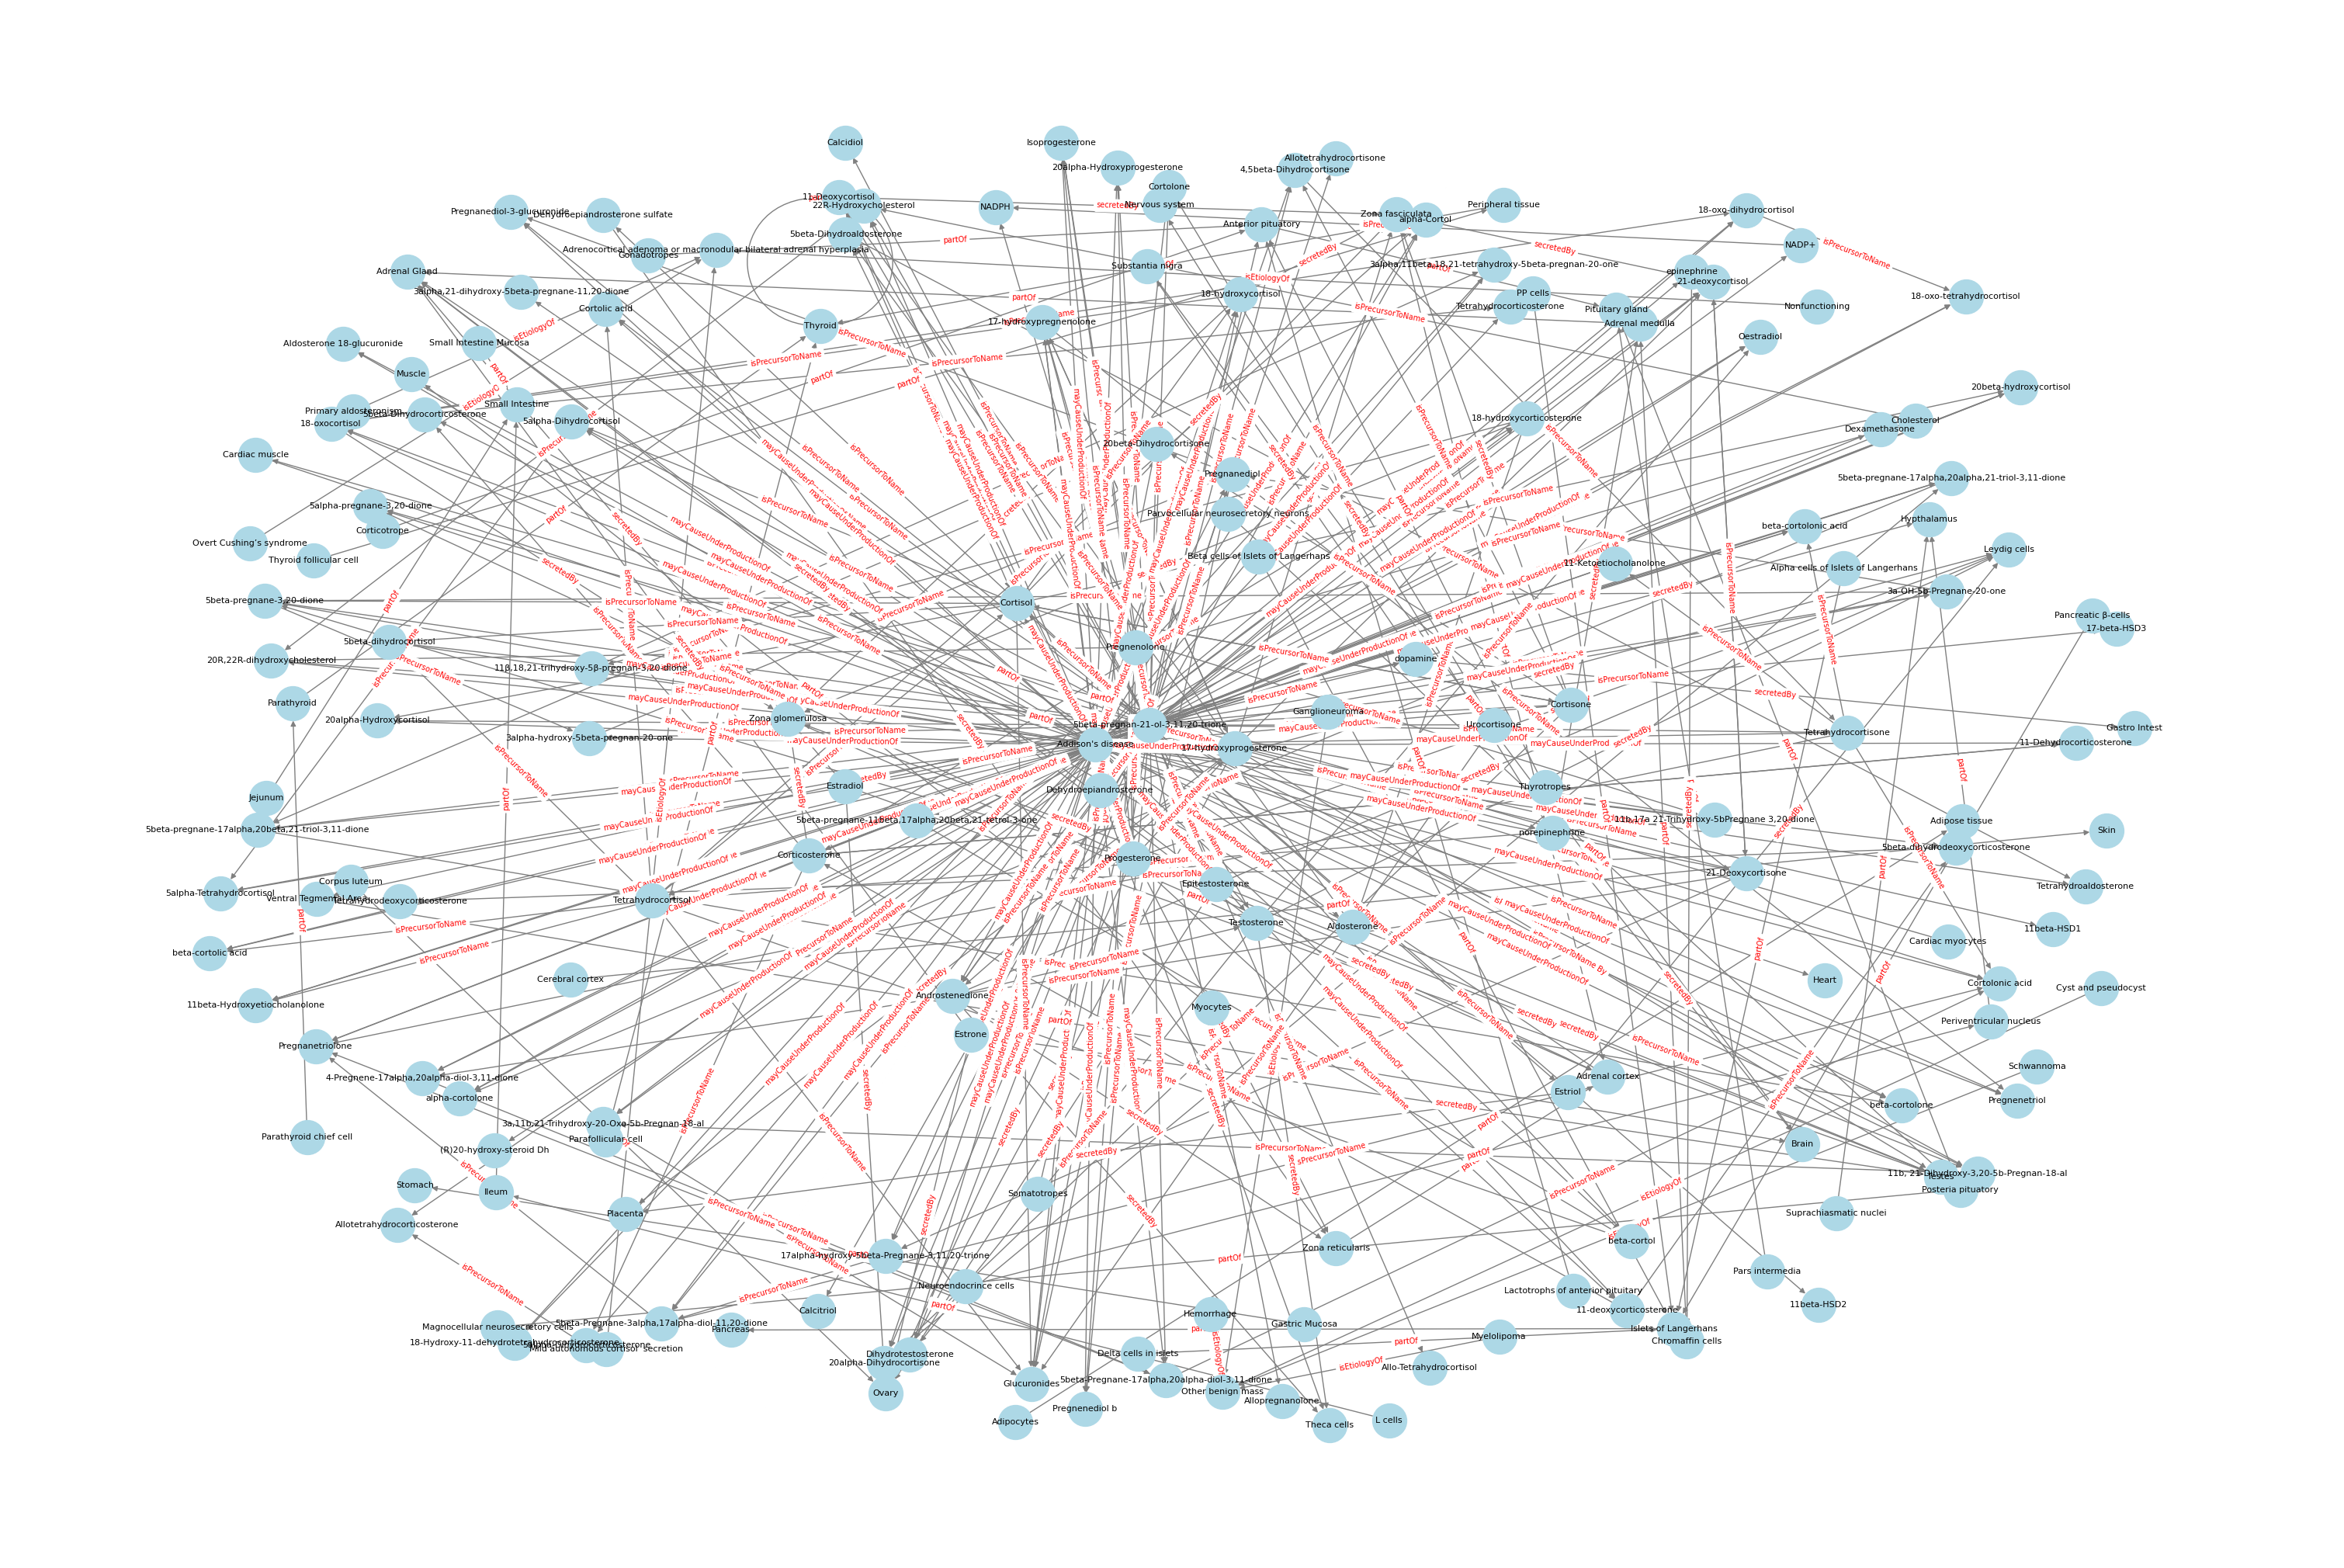

In [10]:
G = nx.DiGraph()

for subj, pred, obj in all_triples:
    G.add_edge(subj, obj, label=pred)

pos = nx.spring_layout(G, k=0.5, iterations=25)

plt.figure(figsize=(30, 20))  # Width, Height in inches

nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1000, font_size=8)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=7)

# Show the plot
plt.show()

### Drawing a subgraph

We are going to look at a subgraph of the triples now, all the persons that are in the Pre Hypertension category.

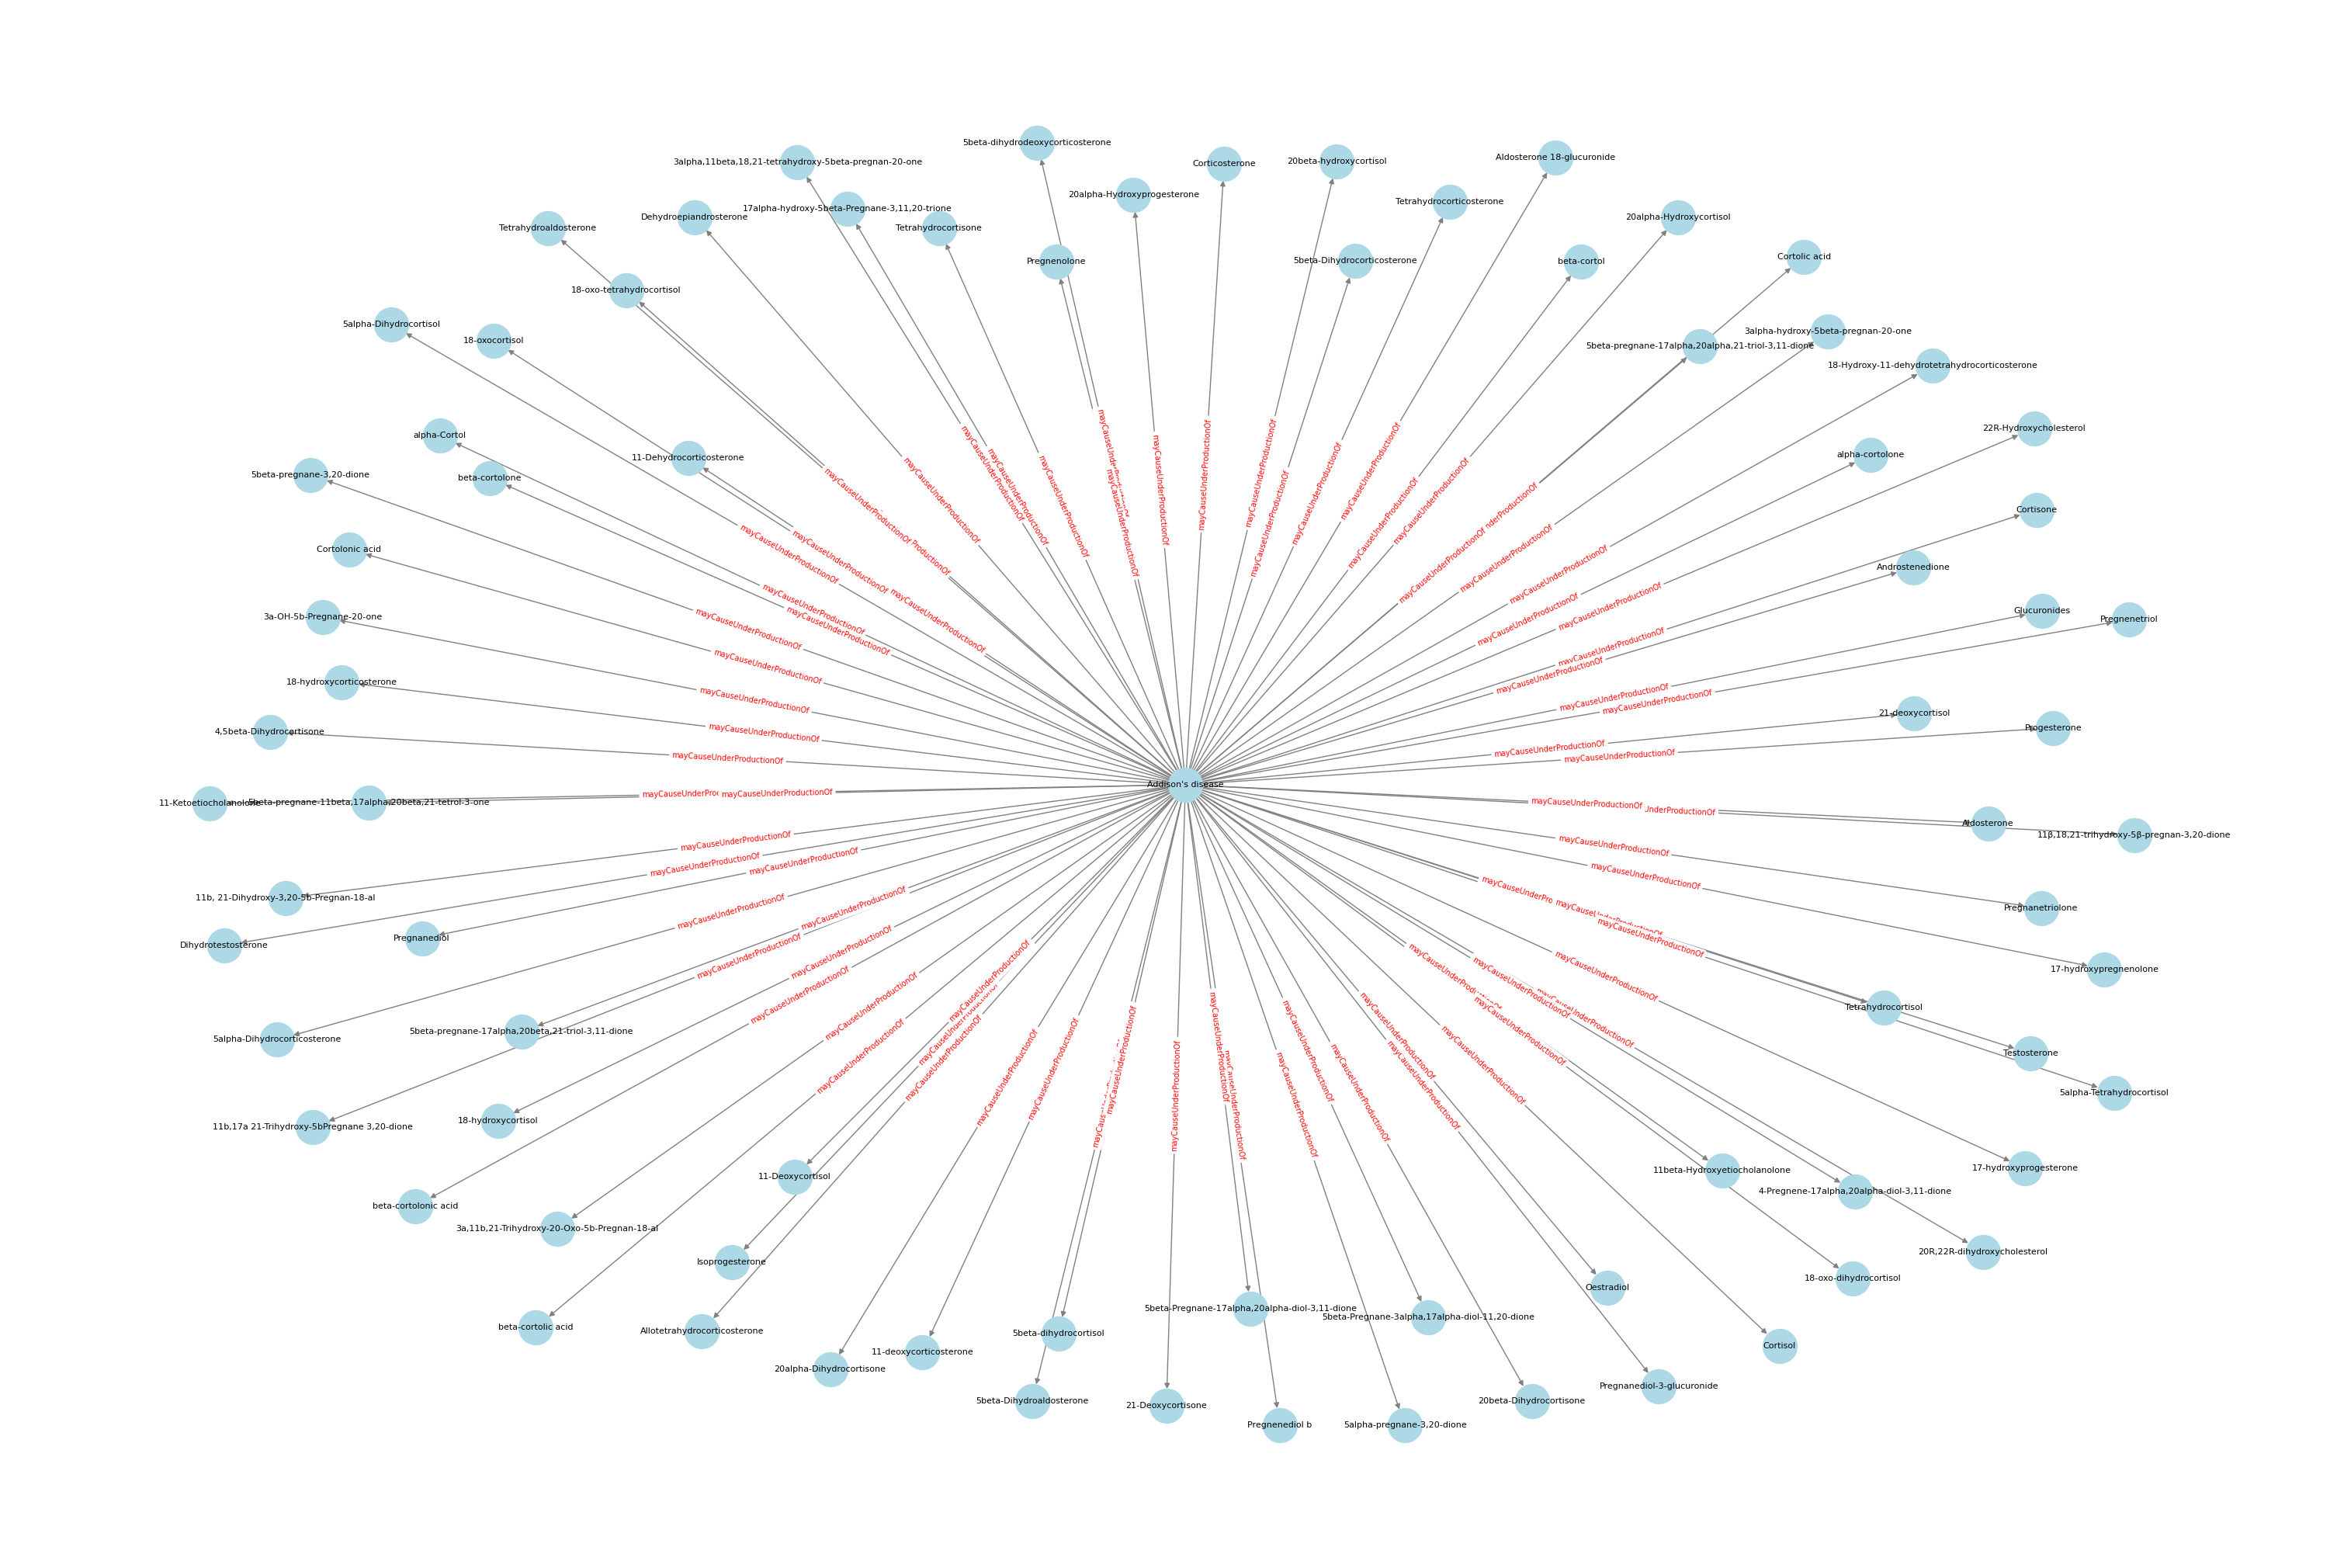

In [11]:
G = nx.DiGraph()

for subj, pred, obj in all_triples:
    if subj.startswith('Addison\'s disease'):
        G.add_edge(subj, obj, label=pred)

pos = nx.spring_layout(G, k=0.5, iterations=25)

plt.figure(figsize=(30, 20))  # Width, Height in inches

nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1000, font_size=8)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=7)

# Show the plot
plt.show()

In [12]:
training_triples = training.mapped_triples
validation_triples = validation.mapped_triples
test_triples = testing.mapped_triples

print("Training Triples:\n", training_triples[:5])
print("Validation Triples:\n", validation_triples[:5])
print("Test Triples:\n", test_triples[:5])

training_triples = training.triples
validation_triples = validation.triples
test_triples = testing.triples

print("\n\nTraining Triples with 'Pre Hypertension' risk factor:")
for triple in training_triples:
    if triple[0] == "Pre Hypertension":
        print(triple)
print("\nValidation Triples with 'Pre Hypertension' risk factor:")
for triple in validation_triples:
    if triple[0] == "Pre Hypertension":
        print(triple)
print("\nTest Triples with 'tourism' relationship:")
for triple in test_triples:
    if triple[0] == "Pre Hypertension":
        print(triple)

Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.


Training Triples:
 tensor([[  1,   1,  78],
        [  2,   4, 166],
        [  4,   1,  46],
        [  5,   1,  30],
        [  6,   1, 157]])
Validation Triples:
 tensor([[166,   3,  56],
        [ 52,   2,  22],
        [ 47,   1,  50],
        [  2,   1,  80],
        [ 16,   4, 167]])
Test Triples:
 tensor([[ 47,   1,  39],
        [ 12,   1,  86],
        [ 47,   1,   6],
        [ 52,   2, 120],
        [ 13,   1,  12]])


Training Triples with 'Pre Hypertension' risk factor:

Validation Triples with 'Pre Hypertension' risk factor:

Test Triples with 'tourism' relationship:


## Training a model

Now we are going to train the embedding model

In [13]:
from pykeen.models import TransE
from pykeen.models import RotatE
from pykeen.losses import SoftplusLoss
from pykeen.losses import MarginRankingLoss
import torch
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

embedding_dim = 1000
# from pykeen.models import ComplEx
# TransE performed the best at validation, but the predictions didn't take into account assymetry
# model = TransE(
#     triples_factory=training,
#     random_seed=35,
#     embedding_dim=embedding_dim,
#     loss=MarginRankingLoss(),
# )
model = RotatE(
    triples_factory=training,
    random_seed=35,
    embedding_dim=embedding_dim,
    loss=MarginRankingLoss(),
)
# model = RotatE(triples_factory=training, random_seed=35, embedding_dim=483, loss=MarginRankingLoss(margin=1.0))
# model = RotatE(triples_factory=training, random_seed=35, embedding_dim=2000)
# model = ComplEx(triples_factory=training, random_seed=35, embedding_dim=1000)


# optimizer = optim.Adam(params=model.get_grad_params())
# optimizer = optim.SGD(params=model.get_grad_params(), lr=0.02)
optimizer = optim.Adagrad(params=model.get_grad_params(), lr=0.028)
# optimizer = optim.SGD(params=model.get_grad_params(), lr=0.001)
from pykeen.evaluation import RankBasedEvaluator
evaluator = RankBasedEvaluator()


from pykeen.sampling import BasicNegativeSampler
negative_sampler = BasicNegativeSampler(
    mapped_triples=training.mapped_triples,
    num_negs_per_pos=1,
)

In [68]:
# lets start with SLCWA.  We can use LCWA
from pykeen.training import SLCWATrainingLoop
training_loop = SLCWATrainingLoop(
    model=model,
    optimizer=optimizer,
    triples_factory=training,
    negative_sampler=negative_sampler,
)

import warnings
warnings.filterwarnings("ignore")

# Training performed in .py file = just for an example
result = training_loop.train(
    triples_factory=training,
    num_epochs=100,
    batch_size=256,
    callbacks="evaluation-loop",
    callbacks_kwargs=dict(
        prefix='validation',
        factory=validation,
    ),
)
    
# Pick an evaluator
mapped_triples_validation = validation.mapped_triples
validation_results = evaluator.evaluate(
    model=model,
    mapped_triples=mapped_triples_validation,
    batch_size=64,
    additional_filter_triples=[
        training.mapped_triples,
        validation.mapped_triples
    ]
)

results = {
    'mean_rank': validation_results.get_metric('mean_rank'),
    'hits@10': validation_results.get_metric('hits@10'),
    'hits@3': validation_results.get_metric('hits@3'),
    'hits@1': validation_results.get_metric('hits@1'),
    'mean_reciprocal_rank': validation_results.get_metric('mean_reciprocal_rank'),
}
stats = {
    'model': 'TransE',
    'dim:': embedding_dim,
    'optim': 'Adagrad',
    'negative_sampler': 'BasicNegativeSampler',
    'neg_samples': 1,
    'hits@10': results['hits@10'],
    'num_epochs': 840,
    'batch_size': 256,
}
print("Validation Results:\n", validation_results)
print("Mean Rank:", validation_results.get_metric('mean_rank'))

Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

Enabled filtered evaluation, but not additional filter triples are passed.
Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.


evaluation:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

...

Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.


evaluation:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/37.0 [00:00<?, ?triple/s]

Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).


Validation Results:
Mean Rank: 37.945945739746094


In [14]:
cortisol_feature_path = "./embeddings/notebook.pt"
# save model's weights to a file
# torch.save(model.state_dict(), cortisol_feature_path)

## Production model

We're going to use the full model now

In [15]:
from pykeen.models import RotatE


# source: https://pykeen.readthedocs.io/en/stable/api/pykeen.checkpoints.save_model.html
# cortisol_feature_path = "./embeddings/cortisol-features.pt"
cortisol_feature_path = "./embeddings/full-training-set.pt"
# save model's weights to a file
# load weights again
state_dict = torch.load(cortisol_feature_path)

model2 = RotatE(triples_factory=triples_factory, random_seed=35, embedding_dim=483, loss=MarginRankingLoss(margin=1.0))
# update the model
pred_model = model2.load_state_dict(state_dict)

## Evaluating the model 

In [ ]:
%%sql


In [31]:
# head_id = triples_factory.entity_to_id['partOf']
triples_factory.relation_to_id['secretedBy']

4

In [103]:
validation.mapped_triples

tensor([[ 47,   1,  86],
        [ 52,   2,  90],
        [ 52,   2, 154],
        [144,   1,  24],
        [ 52,   2,  20],
        [ 47,   1,   5],
        [ 75,   1, 142],
        [ 52,   2,  66],
        [144,   1,  40],
        [ 80,   1,  23],
        [ 47,   1,  80],
        [144,   1,  13],
        [ 52,   2,  12],
        [ 52,   2,  63],
        [ 27,   1,  36],
        [ 80,   1,  26],
        [ 52,   2,   9],
        [ 66,   4, 167],
        [ 47,   1,  49],
        [ 47,   1,  98],
        [ 52,   2,  29],
        [ 52,   2,  49],
        [ 80,   1,  81],
        [ 80,   1,  51],
        [ 47,   1, 172],
        [ 52,   2,  82],
        [ 52,   2,  45],
        [ 47,   1, 174],
        [174,   4, 164],
        [157,   1, 170],
        [ 78,   1,  42],
        [ 92,   4, 153],
        [142,   1, 140],
        [ 47,   1, 158],
        [157,   1,  98],
        [ 80,   1,  98],
        [ 47,   1,  84]])

In [104]:
# Pick an evaluator
from pykeen.evaluation import RankBasedEvaluator
evaluator = RankBasedEvaluator()

# After training and validation evaluation, select the best model

# Now, evaluate the selected/best model on the test set
mapped_triples_test = testing.mapped_triples
test_results = evaluator.evaluate(model,
                                  mapped_triples_test,
                                  batch_size=1024)
print("Test Results:\n", test_results)

The filtered setting was enabled, but there were no `additional_filter_triples`
given. This means you probably forgot to pass (at least) the training triples. Try:

    additional_filter_triples=[dataset.training.mapped_triples]

Or if you want to use the Bordes et al. (2013) approach to filtering, do:

    additional_filter_triples=[
        dataset.training.mapped_triples,
        dataset.validation.mapped_triples,
    ]



Evaluating on cpu:   0%|          | 0.00/36.0 [00:00<?, ?triple/s]

Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).


Test Results:


In [105]:
test_results.get_metric('mean_rank')
test_results.get_metric('hits@10')

0.1388888888888889

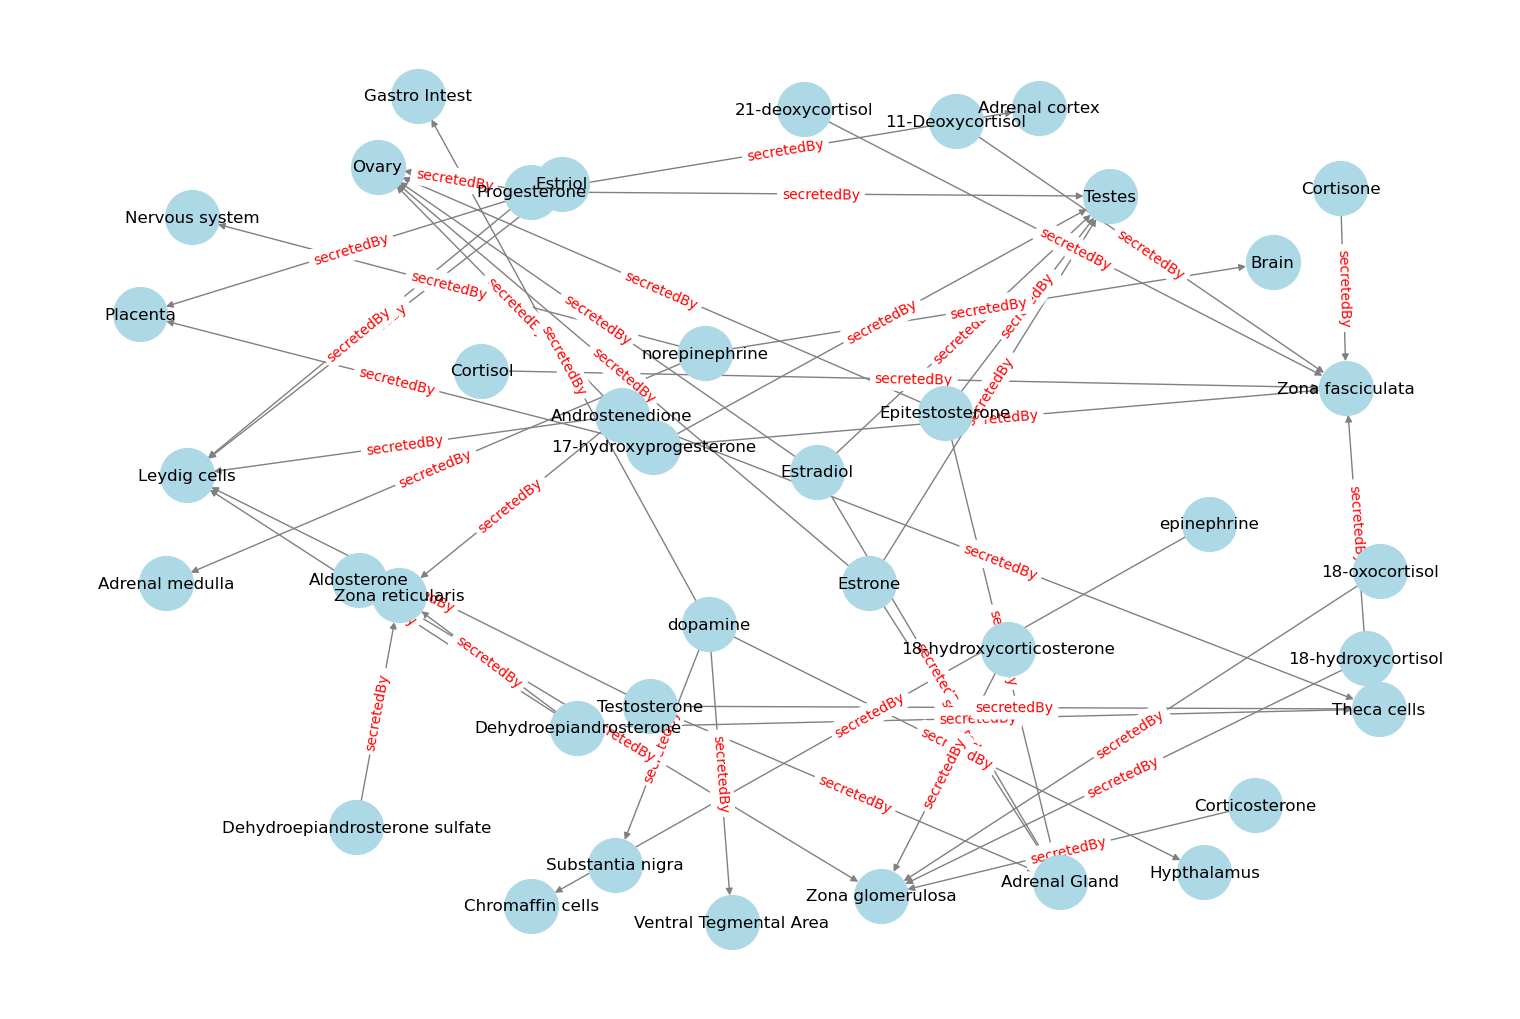

In [106]:
# Visualize the KG for "tourism" edges after evaluation

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph (only include "tourism" edges)
for subj, pred, obj in all_triples:
    if pred == 'secretedBy':
        G.add_edge(subj, obj, label=pred)

# Set a fixed seed for the layout to ensure reproducibility
seed = 42
pos = nx.spring_layout(G, k=0.5, iterations=20, seed=seed)  # Fixed seed for reproducibility

# Set the size of the Matplotlib figure
plt.figure(figsize=(15, 10))  # Width, Height in inches

# Draw the graph
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=12)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

# Show the plot
plt.show()

In [107]:
triples_df

,Hormone,_c1,Organ
0,Cyst and pseudocyst,isEtiologyOf,Other benign mass
1,Primary aldosteronism,isEtiologyOf,Adrenocortical adenoma or macronodular bilater...
2,Hemorrhage,isEtiologyOf,Other benign mass
3,Myelolipoma,isEtiologyOf,Other benign mass
4,Overt Cushing’s syndrome,isEtiologyOf,Adrenocortical adenoma or macronodular bilater...
...,...,...,...
361,Aldosterone,secretedBy,Zona glomerulosa
362,Androstenedione,secretedBy,Zona reticularis
363,Cortisone,secretedBy,Zona fasciculata
364,Dehydroepiandrosterone sulfate,secretedBy,Zona reticularis


### Predictions

Now we're going to use the saved model to make some predictions.  But first we need to filter out and user ids from the predictions. As we only want to see the cortisol features.

In [108]:
triples_df[(triples_df['_c1'] == 'secretedBy') & (triples_df['Organ'] == 'Adrenal Gland')]

,Hormone,_c1,Organ
323,Estradiol,secretedBy,Adrenal Gland
328,Testosterone,secretedBy,Adrenal Gland
331,Estrone,secretedBy,Adrenal Gland
335,Epitestosterone,secretedBy,Adrenal Gland


In [109]:
from pykeen.predict import predict_target
predicted_tails = predict_target(model=model2,tail='Adrenal Gland', relation='secretedBy', triples_factory=triples_factory)
df = predicted_tails.df
df.sort_values(by='score', ascending=False).head(20)

,head_id,score,head_label
94,94,-1.870186,Estrone
91,91,-1.913148,Epitestosterone
92,92,-1.949374,Estradiol
154,154,-2.003425,Testosterone
13,13,-2.637689,17-hydroxyprogesterone
86,86,-2.868233,Dehydroepiandrosterone
47,47,-2.870328,"5beta-pregnan-21-ol-3,11,20-trione"
144,144,-2.883425,Progesterone
66,66,-2.887991,Androstenedione
52,52,-2.985345,Addison's disease


In [32]:
from pykeen.predict import predict_target
predicted_tails = predict_target(model=model2,tail='Ovary', relation='secretedBy', triples_factory=triples_factory)
df = predicted_tails.df
df.sort_values(by='score', ascending=False).head(20)

,head_id,score,head_label
91,91,-1.732670,Epitestosterone
94,94,-1.850611,Estrone
13,13,-1.893697,17-hydroxyprogesterone
92,92,-2.026967,Estradiol
144,144,-2.088988,Progesterone
86,86,-2.799316,Dehydroepiandrosterone
47,47,-2.833278,"5beta-pregnan-21-ol-3,11,20-trione"
154,154,-2.861896,Testosterone
93,93,-2.887237,Estriol
80,80,-2.940851,Cortisol


In [29]:
morning_filter = pd.concat([filter_to_df,filter_feature_from_df])
morning_filter['to'] = 'upperTailMorning'
predicted_tails = predict_target(model=model2,tail='upperTailMorning', relation='hasCortisolFeature', triples_factory=training)
predicted_tails = predicted_tails.filter_triples(morning_filter[['from', 'edge', 'to']].values)
predicted_tails.df

,head_id,score,head_label
220,220,-6.538165,Non-smoker
219,219,-6.619414,Low Waist To Hip Ratio
223,223,-6.671117,Smoker
221,221,-6.680187,Normal Blood Pressure
214,214,-6.730861,BMI:Overweight
216,216,-6.796786,High Blood Pressure Stage 1 Hypertension
218,218,-6.812161,High Waist To Hip Ratio
222,222,-6.840185,Pre Hypertension
217,217,-6.843108,High Blood Pressure Stage 2 Hypertension
215,215,-7.038971,BMI:Underweight


In [95]:
hypertension_filter = pd.concat([filter_to_df,filter_from_df])
hypertension_filter['from'] = 'BMI:Overweight'
predicted_tails = predict_target(model=model2,head='BMI:Overweight', relation='hasCortisolFeature', triples_factory=triples_factory)
predicted_tails = predicted_tails.filter_triples(hypertension_filter[['from', 'edge', 'to']].values)
predicted_tails.df

,tail_id,score,tail_label
224,224,-6.187800,bimodalAfternoon
242,242,-6.230488,upperTailEveningPeak
225,225,-6.331984,bimodalEvening
247,247,-6.394438,upperTailNight
226,226,-6.437528,biomodel
248,248,-6.486119,upperTailNightPeak
236,236,-6.542373,lowerTailNightPeak
250,250,-6.556369,upperTailPeakTime
228,228,-6.592113,lowerTailAfternoonPeak
241,241,-6.610996,upperTailEvening


In [116]:
from_field = 'BMI:Overweight'
hypertension_filter = pd.concat([filter_to_df,filter_from_df])
hypertension_filter['from'] = from_field
predicted_tails = predict_target(model=model2,head=from_field, relation='hasCortisolFeature', triples_factory=triples_factory)
predicted_tails = predicted_tails.filter_triples(hypertension_filter[['from', 'edge', 'to']].values)
predicted_tails.df

,tail_id,score,tail_label
224,224,-6.187800,bimodalAfternoon
242,242,-6.230488,upperTailEveningPeak
225,225,-6.331984,bimodalEvening
247,247,-6.394438,upperTailNight
226,226,-6.437528,biomodel
248,248,-6.486119,upperTailNightPeak
236,236,-6.542373,lowerTailNightPeak
250,250,-6.556369,upperTailPeakTime
228,228,-6.592113,lowerTailAfternoonPeak
241,241,-6.610996,upperTailEvening


In [113]:
from pykeen.predict import predict_all

pack = predict_all(model=model2)
pred = pack.process(factory=triples_factory)
pred.df

predict is an expensive operation, involving 158,420 score evaluations.
Not providing k to `predict_all` entails huge memory requirements for reasonably-sized knowledge graphs.


scoring:   0%|          | 0.00/890 [00:00<?, ?batch/s]

,head_id,head_label,relation_id,relation_label,tail_id,tail_label,score
0,157,Tetrahydrocortisol,1,isPrecursorToName,171,beta-cortol,-1.610850
1,80,Cortisol,1,isPrecursorToName,6,"11b,17a 21-Trihydroxy-5bPregnane 3,20-dione",-1.638847
2,47,"5beta-pregnan-21-ol-3,11,20-trione",1,isPrecursorToName,169,alpha-Cortol,-1.642729
3,158,Tetrahydrocortisone,1,isPrecursorToName,84,Cortolonic acid,-1.667149
4,157,Tetrahydrocortisol,1,isPrecursorToName,172,beta-cortolic acid,-1.681761
...,...,...,...,...,...,...,...
158415,113,Myelolipoma,3,partOf,114,Myocytes,-4.251493
158416,146,Skin,1,isPrecursorToName,146,Skin,-4.255007
158417,118,Neuroendocrince cells,3,partOf,146,Skin,-4.260351
158418,113,Myelolipoma,4,secretedBy,152,Suprachiasmatic nuclei,-4.270383


In [ ]:
triples_factory.